# preparing tables and figures for the thesis

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Helper Functions

def print_stats_per_roi(region_name):
    roi_data = df[df["region_name"] == region_name]
    for age_bin in roi_data["age_bin"].unique():
        bin_data = roi_data[roi_data["age_bin"] == age_bin]
        print(f"Age Bin {age_bin}, coef={bin_data['coef'].iloc[0]}, t={bin_data['t'].iloc[0]}, fdr_p={bin_data['fdr_p'].iloc[0]}")

# Metadata

In [3]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')

In [4]:
# keep a row per session (subject_id + session_id) 
scans = combined_df.drop_duplicates(subset=['subject_id', 'session_id'])

In [5]:
# Combined metadata across the first 3 age windows together (20-35), matching
# step9's canonical bins [20,25) + [25,30) + [30,35) = [20,35). n_subjects here
# is deduped ONCE across the whole 20-35 range (not per-bin), so it's expected
# to be lower than n_scans — a subject scanned in two different sub-bins only
# counts once. Per-bin breakdowns (one bin at a time) already exist in step9.
import sys
sys.path.insert(0, '/home/gaia/Projects/legacy_data/legacy_pipe')
from src.cleaning_funcs import print_metadata

scans_20_35 = scans[(scans['age_in_years'] >= 20) & (scans['age_in_years'] < 35)]
print("=== Combined metadata: ages 20-35 (all 3 windows together) ===")
print_metadata(scans_20_35)

=== Combined metadata: ages 20-35 (all 3 windows together) ===
metadata stats: 3367 scans, 2593 subjects
percentage of female subjects: 44.66%
percentage of male subjects: 55.34%
subjects age 20-25: 985
subjects age 25-30: 1082
subjects age 30-35: 595
age: 20.00–34.99, mean 26.88, std 3.65
birth year: 1971–2005, mean 1993.84, std 6.19


In [6]:
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")

# FDR-bug-fixed version: FDR now corrected only across weighting == 'weighted'
# birth_year p-values per window (454 ROIs), instead of pooling weighted +
# unweighted p-values together (908 tests). See step9_refactored_windowing_weighting.ipynb.
coef_df = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/weightedFDRonly_coef_df_manual_bins_wuniform.csv')

# take only interesting bins: [20, 25), [25, 30), [30, 35)
coef_df = coef_df[coef_df['age_bin'].isin(['[20, 25)', '[25, 30)', '[30, 35)'])]

weighted_birth_year_coef_df = coef_df[
    (coef_df['variable'] == 'birth_year') & (coef_df['weighting'] == 'weighted')
]
# rename the column 'index' to 'region_label'
atlas_csv = atlas_csv.rename(columns={'index': 'region_label'})

# add the network and component information to the birth_year_coef_df
weighted_birth_year_coef_df = weighted_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')

In [7]:
col_list = ['region_label', 'region_name', 'coef', 't', 'fdr_p' ]
dec = 3

for age_bin in coef_df['age_bin'].unique():
    sub_df = weighted_birth_year_coef_df[weighted_birth_year_coef_df['age_bin'] == age_bin]
    print(f"Age bin: {age_bin}, n_subjects = {sub_df['n_subjects'].iloc[0]}, ess = {sub_df['ess'].iloc[0]}")
    # keep columns that are in col_list
    sub_df = sub_df[col_list]

    # keep only dec numbers after the decimal point
    for col in sub_df.columns:
        if col in ['coef', 't', 'fdr_p']:
            sub_df[col] = sub_df[col].round(dec)
    # save table so I can export to csv
    # sub_df.to_csv(f"/home/gaia/Projects/legacy_data/legacy_pipe/docs/weighted_birth_year_coef_df_{age_bin}.csv", index=False)


Age bin: [20, 25), n_subjects = 985, ess = 486.14346071444106
Age bin: [25, 30), n_subjects = 1086, ess = 622.4060780308131
Age bin: [30, 35), n_subjects = 597, ess = 321.9913354870095


In [8]:
print(weighted_birth_year_coef_df.columns)

Index(['age_bin', 'region_label', 'variable', 'weighting', 'coef', 't', 'p',
       'n_subjects', 'ess', 'index', 'region_name', 'fdr_p', 'network',
       'component', 'hemisphere'],
      dtype='str')


In [9]:
# load stability summary files for each age window
import json
from pathlib import Path

# 1. Define the base directory
base_dir = Path("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim")

# 2. Define a helper to load and report
def load_roi_list(filename):
    file_path = base_dir / filename
    with open(file_path, "r") as f:
        data = json.load(f)
    print(f"✅ Loaded {len(data):<3} ROIs from: {filename}")
    return data

# 3. Clean loading
early_twenties_roi_list_95 = load_roi_list("stable_95_early_twenties.json")
late_twenties_roi_list_95  = load_roi_list("stable_95_late_twenties.json")
early_thirties_roi_list_95 = load_roi_list("stable_95_early_thirties.json")

# fill stable_95
weighted_birth_year_coef_df.loc[
    (weighted_birth_year_coef_df['age_bin'] == '[20, 25)') & 
    (weighted_birth_year_coef_df['region_label'].isin(early_twenties_roi_list_95)), 
    'stable_95'
] = True

weighted_birth_year_coef_df.loc[
    (weighted_birth_year_coef_df['age_bin'] == '[25, 30)') & 
    (weighted_birth_year_coef_df['region_label'].isin(late_twenties_roi_list_95)), 
    'stable_95'
] = True

weighted_birth_year_coef_df.loc[
    (weighted_birth_year_coef_df['age_bin'] == '[30, 35)') & 
    (weighted_birth_year_coef_df['region_label'].isin(early_thirties_roi_list_95)), 
    'stable_95'
] = True


print(f"Any True values in age_bin 20-25? {weighted_birth_year_coef_df[weighted_birth_year_coef_df['age_bin'] == '[20, 25)']['stable_95'].any()}")
print(f"Any True values in age_bin 25-30? {weighted_birth_year_coef_df[weighted_birth_year_coef_df['age_bin'] == '[25, 30)']['stable_95'].any()}")
print(f"Any True values in age_bin 30-35? {weighted_birth_year_coef_df[weighted_birth_year_coef_df['age_bin'] == '[30, 35)']['stable_95'].any()}")

✅ Loaded 173 ROIs from: stable_95_early_twenties.json
✅ Loaded 128 ROIs from: stable_95_late_twenties.json
✅ Loaded 180 ROIs from: stable_95_early_thirties.json
Any True values in age_bin 20-25? True
Any True values in age_bin 25-30? True
Any True values in age_bin 30-35? True


In [10]:
# rename for easier access
df = weighted_birth_year_coef_df.copy()
df['sig_stab'] = (df['fdr_p'] < 0.05) & (df['stable_95'] == True)
sig_stab_df = df[df['sig_stab'] == True]

In [11]:
print(df.columns)

Index(['age_bin', 'region_label', 'variable', 'weighting', 'coef', 't', 'p',
       'n_subjects', 'ess', 'index', 'region_name', 'fdr_p', 'network',
       'component', 'hemisphere', 'stable_95', 'sig_stab'],
      dtype='str')


In [12]:
# print the % or significant stable roi per window and mean across all windows (cortical and subcortical)

# Plots

## Section 1 - General 

In [13]:
# percentage of ROIs that are stable and significant in each age window per network
# create a df of the percentage of stable ROIs per network per age window
results = []
age_windows = ['[20, 25)', '[25, 30)', '[30, 35)']
networks = df['network'].unique()
for network in networks:
    network_df = df[df['network'] == network]
    # calculate the % of significant and stable rois out of all network's rois
    n_stable = network_df[network_df['sig_stab'] == True].shape[0]
    percentage_stable = (n_stable / network_df.shape[0] * 100) if network_df.shape[0] > 0 else 0
    print(f"% of stable ROIs in Network {network}: {percentage_stable:.2f}%")
    for age_window in age_windows:
        sub_df = df[(df['age_bin'] == age_window) & (df['network'] == network)]
        n_stable = sub_df[sub_df['sig_stab'] == True].shape[0]
        percentage_stable = (n_stable / sub_df.shape[0] * 100) if sub_df.shape[0] > 0 else 0
        results.append((age_window, network, percentage_stable))
        print(f"Age window {age_window}, Network {network}: {percentage_stable:.2f}% of significant ROIs are stable.")


% of stable ROIs in Network visual: 15.85%
Age window [20, 25), Network visual: 16.39% of significant ROIs are stable.
Age window [25, 30), Network visual: 11.48% of significant ROIs are stable.
Age window [30, 35), Network visual: 19.67% of significant ROIs are stable.
% of stable ROIs in Network somatomotor: 50.65%
Age window [20, 25), Network somatomotor: 57.14% of significant ROIs are stable.
Age window [25, 30), Network somatomotor: 42.86% of significant ROIs are stable.
Age window [30, 35), Network somatomotor: 51.95% of significant ROIs are stable.
% of stable ROIs in Network dorsal attention: 17.39%
Age window [20, 25), Network dorsal attention: 13.04% of significant ROIs are stable.
Age window [25, 30), Network dorsal attention: 6.52% of significant ROIs are stable.
Age window [30, 35), Network dorsal attention: 32.61% of significant ROIs are stable.
% of stable ROIs in Network salience / ventral attention: 61.70%
Age window [20, 25), Network salience / ventral attention: 65.9

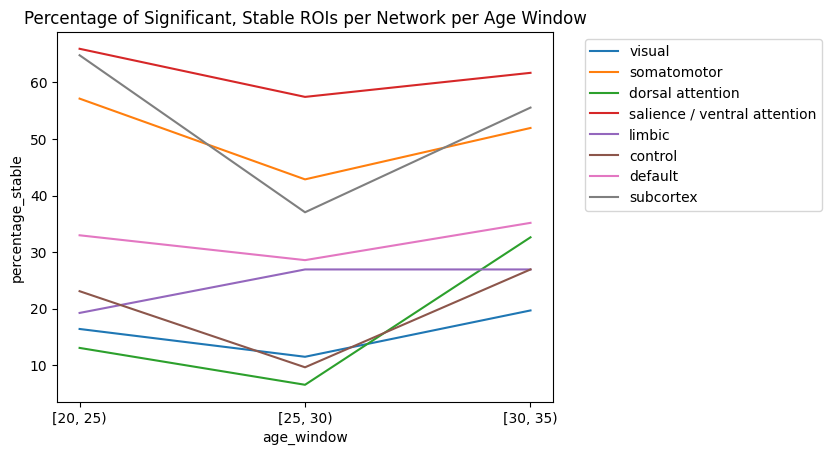

In [14]:
# plot the results as a line plot - y axis is percentage of stable ROIs, x axis is age window, one line per network
import matplotlib.pyplot as plt
import seaborn as sns


df_results = pd.DataFrame(results, columns=['age_window', 'network', 'percentage_stable'])
sns.lineplot(data=df_results, x='age_window', y='percentage_stable', hue='network')

# title - pecentage of significant, stable ROIs per network per age window
plt.title('Percentage of Significant, Stable ROIs per Network per Age Window')

# move the legend outside of the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Brain Plots

### Setup

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yabplot as yp

# ── Global Paths & Config ────────────────────────────────────────────────----
SUB_ATLAS_PATH = "/home/gaia/Projects/legacy_data/legacy_pipe/models/atlases/subcortical/tian2020_s7"

# ── Data Preprocessing (Run Once) ───────────────────────────────────────────
# Mask for significant & stable ROIs
df["plot_coef"] = np.where(df["sig_stab"], df["coef"], np.nan)
df["is_cortical"] = df["region_name"].str.startswith("7Networks_")


# ── Helper 1: Quick Brain Plotter ───────────────────────────────────────────
def render_brain(
    data_dict,
    vminmax=[-14, 14],
    cmap="coolwarm",
    title=None,
    is_cortical=True,
):
    """Generic wrapper to plot cortical or subcortical dictionary mapping."""
    if not data_dict:
        print("No regions to plot.")
        return

    if title:
        print(f"\n---> {title}")

    if is_cortical:
        yp.plot_cortical(
            data=data_dict,
            atlas="schaefer400",
            vminmax=vminmax,
            cmap=cmap,
            nan_color=(0.85, 0.85, 0.85),
            display_type="static",
        )
    else:
        yp.plot_subcortical(
            data=data_dict,
            custom_atlas_path=SUB_ATLAS_PATH,
            vminmax=vminmax,
            cmap=cmap,
            nan_color=(0.85, 0.85, 0.85),
            display_type="static",
        )


# ── Helper 2: Separate Cortical/Subcortical and Plot Both ───────────────────
def plot_brain_pair(data_dict, vminmax=[-14, 14], cmap="coolwarm", title=None):
    """Splits a region->val dict into cortical/subcortical and plots both."""
    cortical = {k: v for k, v in data_dict.items() if k.startswith("7Networks_")}
    subcortical = {
        k: v for k, v in data_dict.items() if not k.startswith("7Networks_")
    }

    if cortical:
        render_brain(
            cortical,
            vminmax=vminmax,
            cmap=cmap,
            title=f"{title} (Cortical)" if title else None,
            is_cortical=True,
        )
    if subcortical:
        render_brain(
            subcortical,
            vminmax=vminmax,
            cmap=cmap,
            title=f"{title} (Subcortical)" if title else None,
            is_cortical=False,
        )

B. Plot Mean Coefficients per Network (Averaged across Age Bins)


---> Network: control (Averaged Bins) (Cortical)


2026-08-10 14:52:03.238 (   0.921s) [    717FFB1E3080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


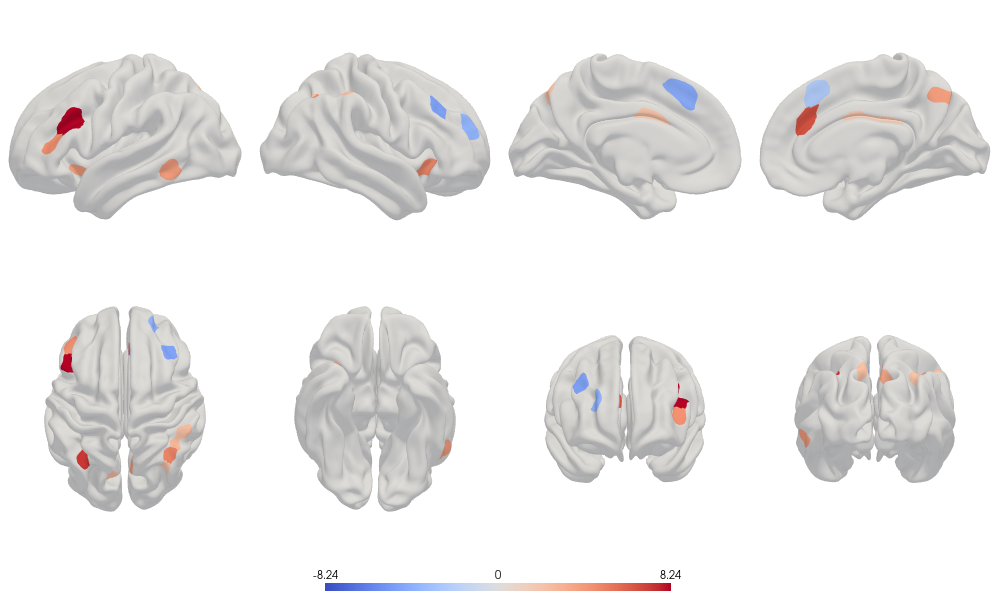


---> Network: default (Averaged Bins) (Cortical)


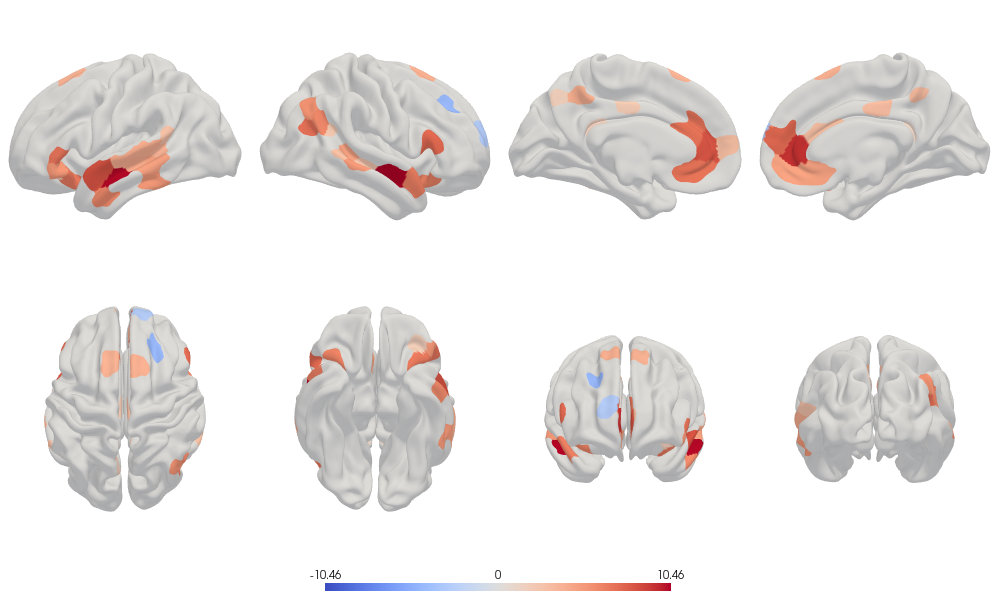


---> Network: dorsal attention (Averaged Bins) (Cortical)


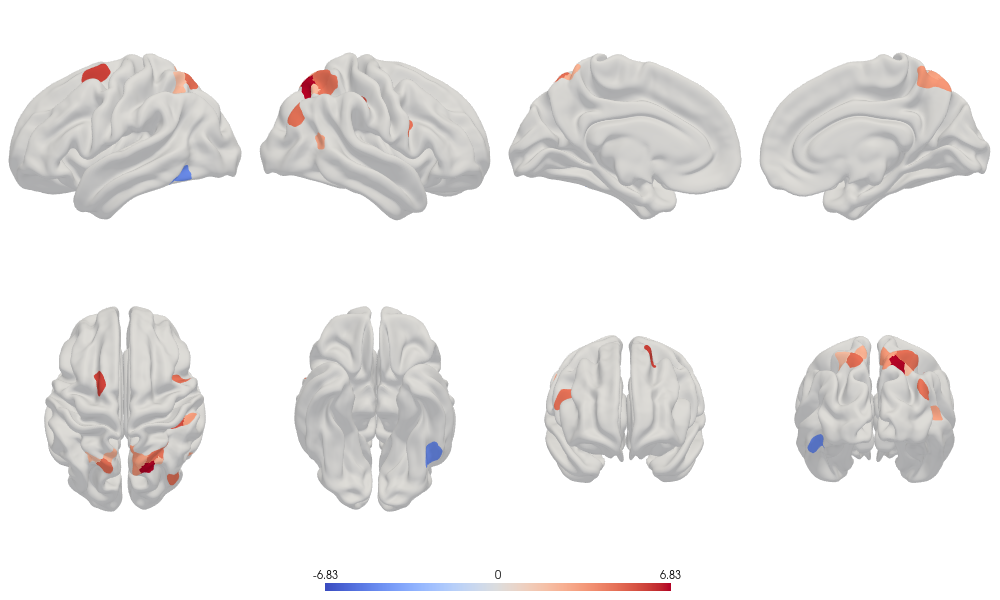


---> Network: limbic (Averaged Bins) (Cortical)


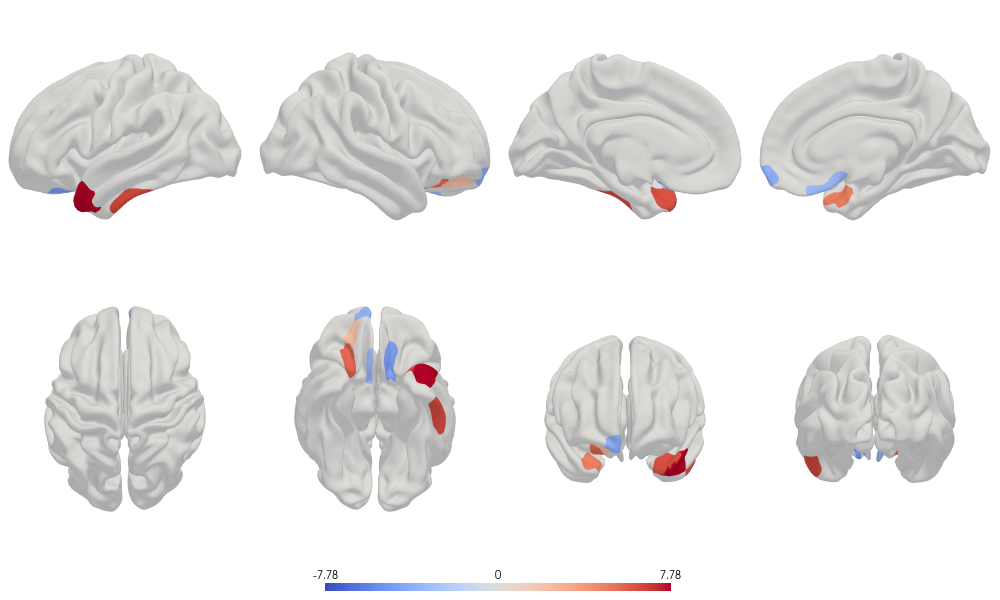


---> Network: salience / ventral attention (Averaged Bins) (Cortical)


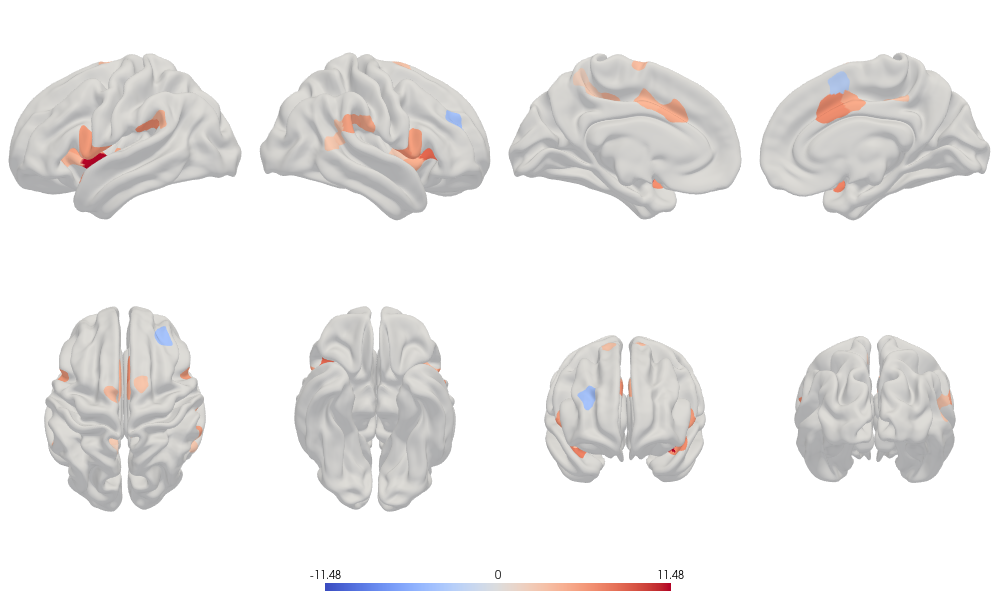


---> Network: somatomotor (Averaged Bins) (Cortical)


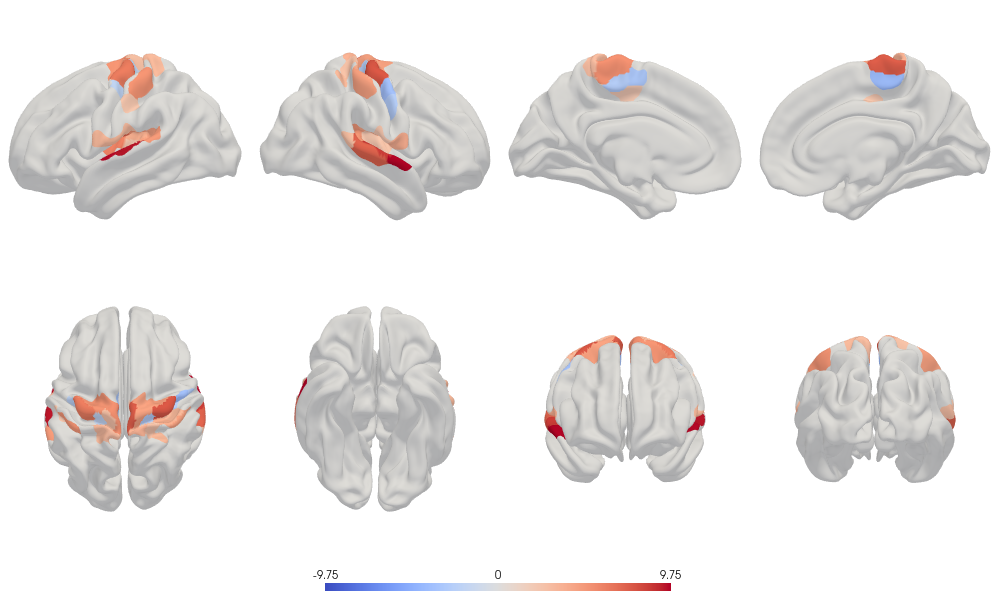


---> Network: subcortex (Averaged Bins) (Subcortical)


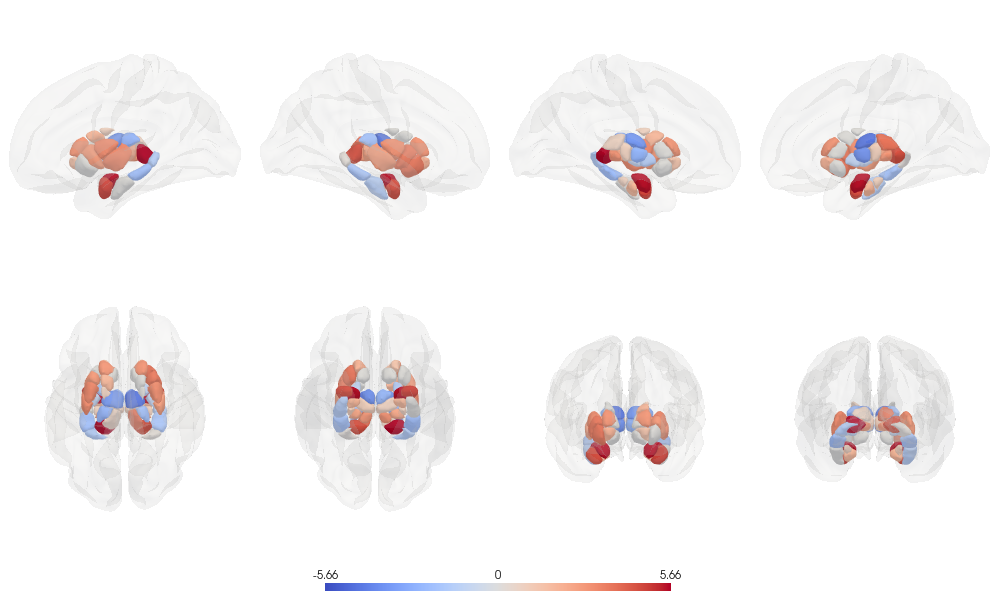


---> Network: visual (Averaged Bins) (Cortical)


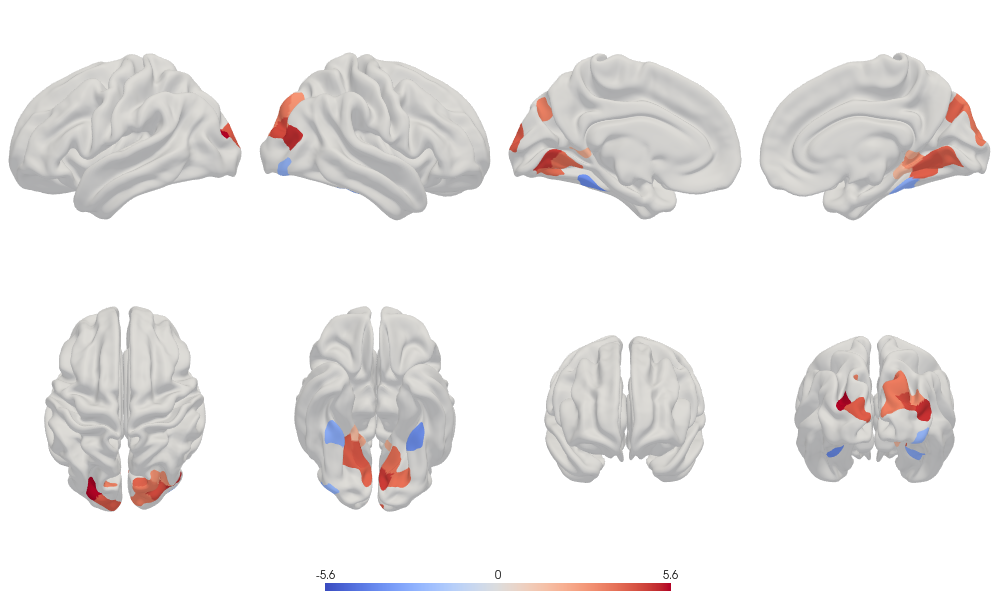

In [16]:
# Average significant/stable coefficients across age bins per region
from tangled_up_in_unicode import decimal


avg_df = (
    df.dropna(subset=["plot_coef"])
    .groupby(["network", "region_name"])["plot_coef"]
    .mean()
    .reset_index()
)

# Loop and plot 1 brain pair per network
for network, group in avg_df.groupby("network"):
    data_dict = dict(zip(group["region_name"], group["plot_coef"]))
    min_limit = round(min(data_dict.values()), 2)
    max_limit = round(max(data_dict.values()), 2)
    limit = max(abs(min_limit), abs(max_limit))
    plot_brain_pair(
        data_dict,
        vminmax=[-limit, limit],
        title=f"Network: {network} (Averaged Bins)",
    )


C. Plot Significant & Stable ROIs for ONE Specific Network & Age Bin

In [17]:
target_net = "SalVentAttn"
target_bin = 1  # Replace with your age_bin value

filtered = df[
    (df["network"] == target_net)
    & (df["age_bin"] == target_bin)
    & df["plot_coef"].notna()
]
data_dict = dict(zip(filtered["region_name"], filtered["plot_coef"]))

plot_brain_pair(
    data_dict,
    vminmax=[-14, 14],
    title=f"{target_net} - Age Bin {target_bin}",
)

color by age bin count

In [18]:
from matplotlib.colors import ListedColormap

# ── Step 1: Calculate roi_count (Repetitions across age_bins) ─────────────────
# Count how many age bins each region was BOTH significant and stable
roi_counts = (
    df[df["sig_stab"] == True]
    .groupby("region_name")["age_bin"]
    .nunique()
    .reset_index(name="roi_count")
)

# Merge counts back onto the unique region-network mapping
region_net_map = df[
    ["region_name", "network"]
].drop_duplicates()
count_df = region_net_map.merge(
    roi_counts, on="region_name", how="left"
).fillna({"roi_count": 0})

# order count_df by network and by roi_count (descending)
count_df = count_df.sort_values(["network", "roi_count"], ascending=[True, False])

# print per network the rois and their roi count
for network in count_df["network"].unique():
    print(f"Network: {network}")
    net_rois = count_df[(count_df["network"] == network) & (count_df["roi_count"] > 1)]
    for _, row in net_rois.iterrows():
        print(f"  {row['region_name']}: {row['roi_count']}")



Network: control
  7Networks_LH_Cont_PFCv_1: 3.0
  7Networks_RH_Cont_PFCv_1: 3.0
  7Networks_RH_Cont_Cing_2: 3.0
  7Networks_RH_Cont_PFCmp_1: 3.0
  7Networks_LH_Cont_pCun_1: 2.0
  7Networks_RH_Cont_pCun_1: 2.0
Network: default
  7Networks_LH_Default_Temp_4: 3.0
  7Networks_LH_Default_Temp_5: 3.0
  7Networks_LH_Default_Temp_7: 3.0
  7Networks_LH_Default_Temp_8: 3.0
  7Networks_LH_Default_PFC_1: 3.0
  7Networks_LH_Default_PFC_4: 3.0
  7Networks_LH_Default_PFC_9: 3.0
  7Networks_LH_Default_pCunPCC_9: 3.0
  7Networks_RH_Default_Par_3: 3.0
  7Networks_RH_Default_Temp_4: 3.0
  7Networks_RH_Default_Temp_5: 3.0
  7Networks_RH_Default_Temp_6: 3.0
  7Networks_RH_Default_Temp_7: 3.0
  7Networks_RH_Default_Temp_8: 3.0
  7Networks_RH_Default_PFCv_1: 3.0
  7Networks_RH_Default_PFCdPFCm_3: 3.0
  7Networks_LH_Default_Temp_1: 2.0
  7Networks_LH_Default_Temp_6: 2.0
  7Networks_LH_Default_PFC_8: 2.0
  7Networks_LH_Default_PFC_12: 2.0
  7Networks_LH_Default_pCunPCC_4: 2.0
  7Networks_LH_Default_pCunPCC_10


---> Network: control (ROI Repetitions Across Bins) (Cortical)


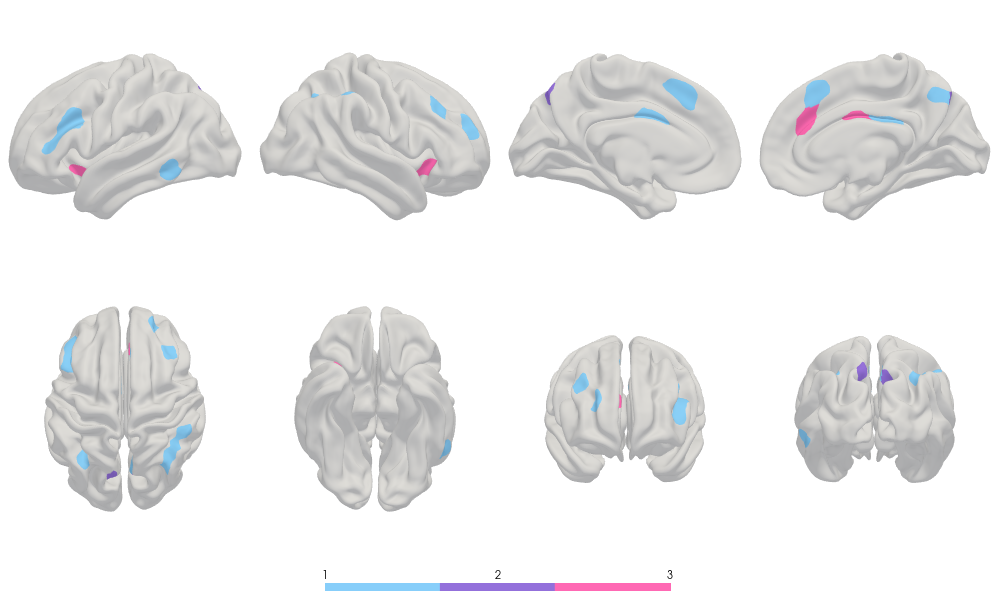


---> Network: default (ROI Repetitions Across Bins) (Cortical)


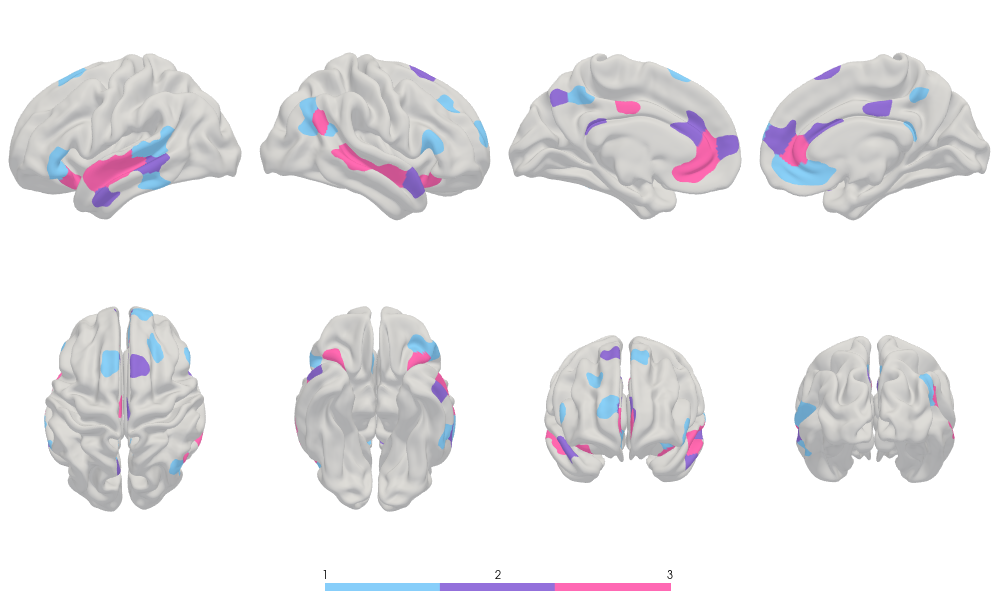


---> Network: dorsal attention (ROI Repetitions Across Bins) (Cortical)


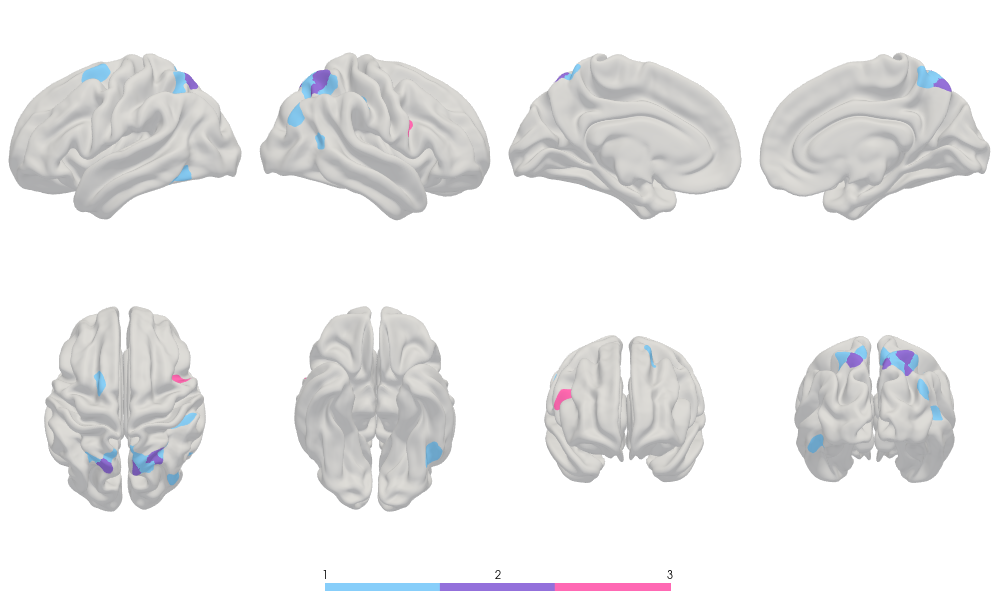


---> Network: limbic (ROI Repetitions Across Bins) (Cortical)


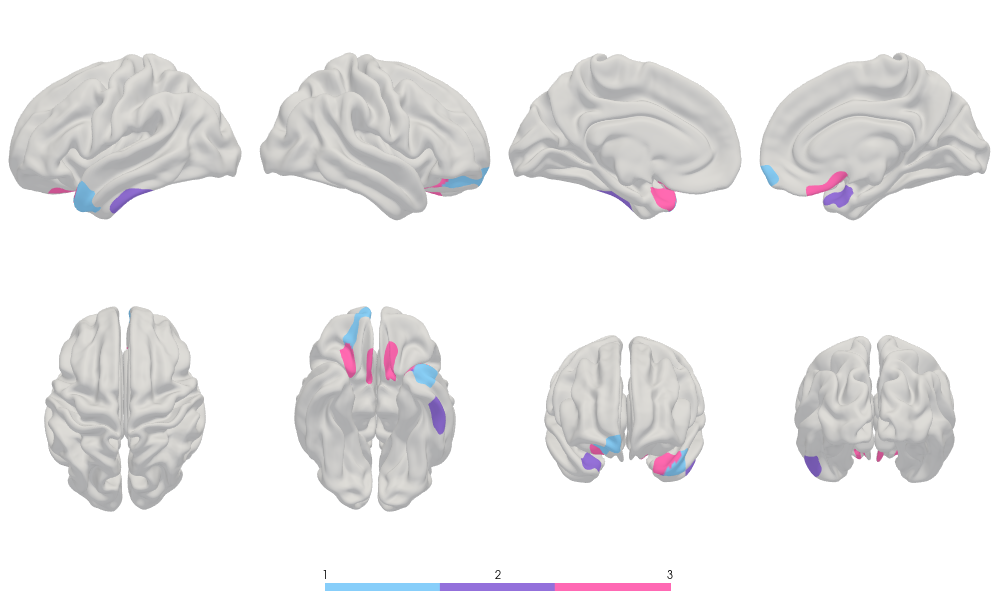


---> Network: salience / ventral attention (ROI Repetitions Across Bins) (Cortical)


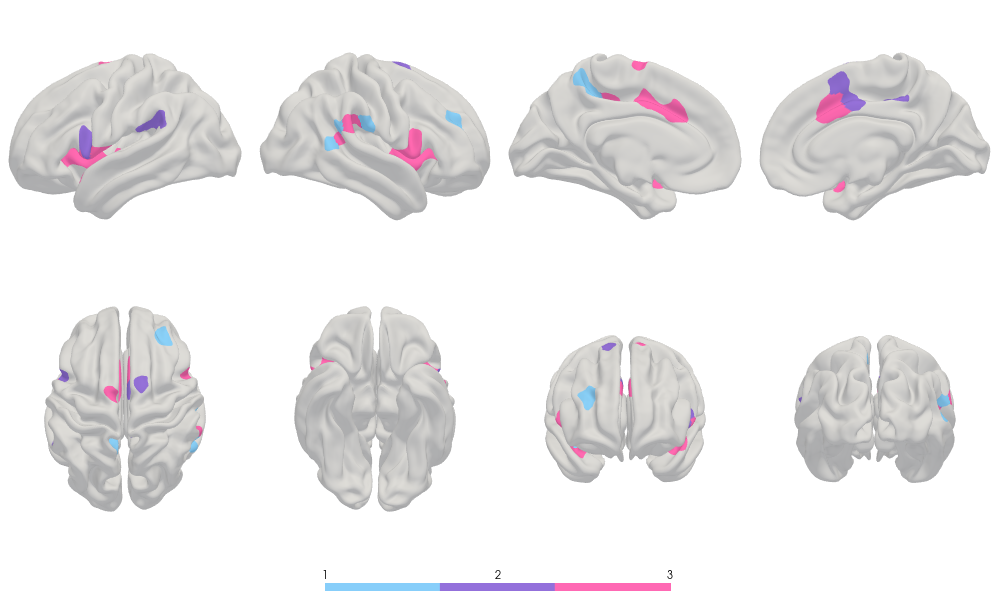


---> Network: somatomotor (ROI Repetitions Across Bins) (Cortical)


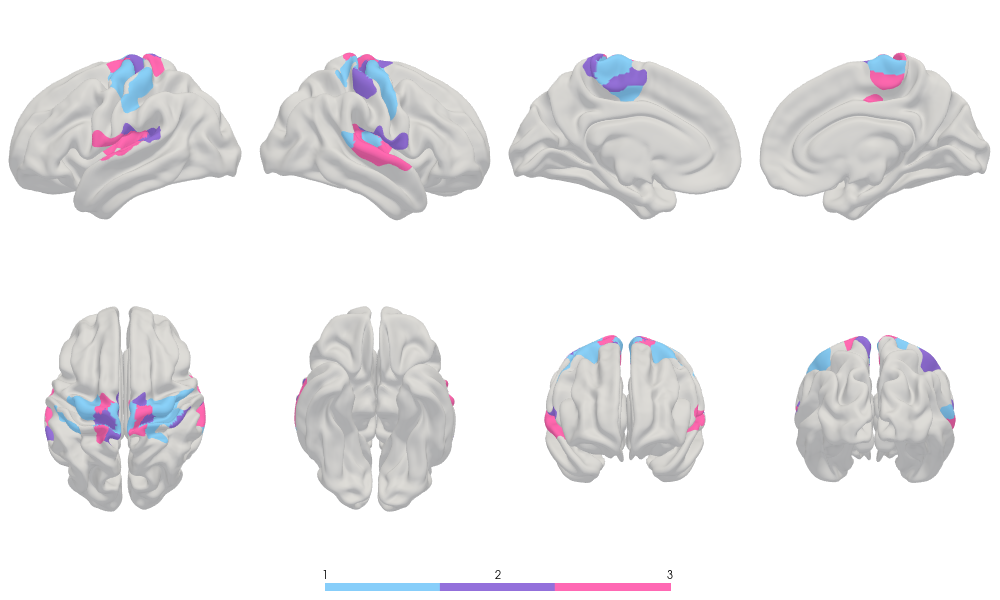


---> Network: subcortex (ROI Repetitions Across Bins) (Subcortical)


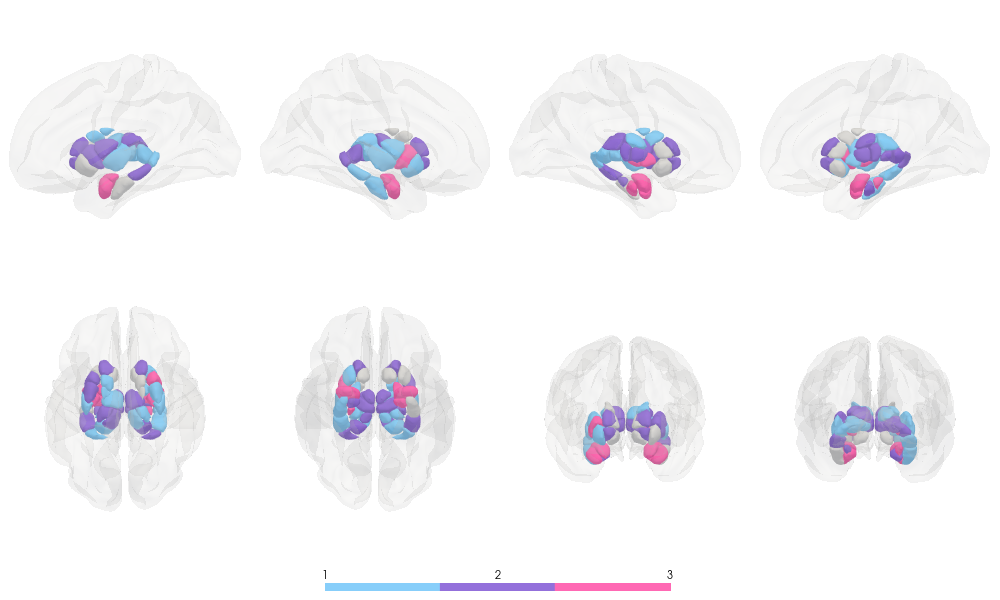


---> Network: visual (ROI Repetitions Across Bins) (Cortical)


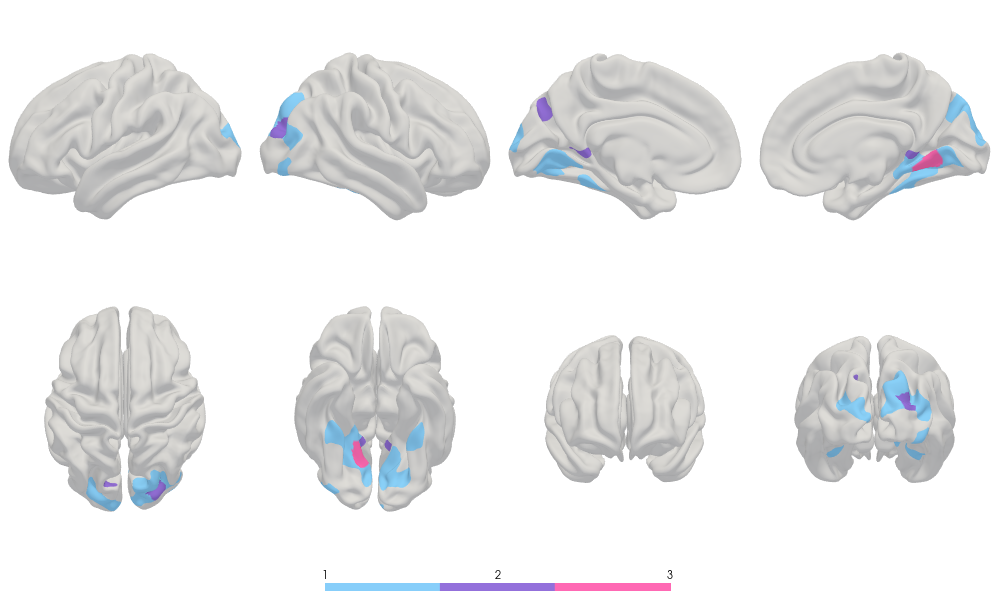

In [19]:
# ── Step 2: Define Discrete Colormap ─────────────────────────────────────────
# 1 = lightskyblue, 2 = mediumpurple, 3 = hotpink
custom_cmap = ListedColormap(["lightskyblue", "mediumpurple", "hotpink"])

# ── Step 3: Loop per Network and Plot ─────────────────────────────────────────
for network, group in count_df.groupby("network"):

    # Filter to regions in this network that appeared at least once (> 0)
    net_dict = {
        row["region_name"]: float(row["roi_count"])
        for _, row in group.iterrows()
        if row["roi_count"] > 0
    }

    # Plot using your existing boilerplate helper
    plot_brain_pair(
        net_dict,
        vminmax=[1, 3],
        cmap=custom_cmap,
        title=f"Network: {network} (ROI Repetitions Across Bins)",
    )

In [20]:
# in sig_stab_df print a table with coef and t values of the input region_name 
print_stats_per_roi('7Networks_LH_SalVentAttn_FrOperIns_7')


Age Bin [20, 25), coef=3.7643386731388944, t=8.796866758098103, fdr_p=6.43783782033431e-17
Age Bin [25, 30), coef=3.709648795952928, t=9.310204396164126, fdr_p=1.6494412165346682e-18
Age Bin [30, 35), coef=2.9259171413997347, t=5.827229811469039, fdr_p=1.6169446162631286e-07


In [21]:
# Do all fdr_p values are <0.001 in sig_stab_df? 
print((sig_stab_df["fdr_p"] < 0.001).all())

# which region_name in not fdr_p<0.001? 
manual_fdr = sig_stab_df[sig_stab_df["fdr_p"] >= 0.001]["region_name"]

False


# Tables to export, edit and paste in the results 

In [22]:

roi_list = ['7Networks_LH_Default_Temp_4',
             '7Networks_LH_Default_PFC_1',
             '7Networks_LH_Default_PFC_4',
             '7Networks_LH_Default_PFC_12',
             '7Networks_RH_Default_Par_5',
             '7Networks_RH_Default_Temp_8',
             '7Networks_RH_Default_PFCdPFCm_3']

temp_dp = sig_stab_df[sig_stab_df['region_name'].isin(roi_list)]

# keep the columns region_name, age_bin, coef, t, fdr_p
temp_dp = temp_dp[['region_name', 'age_bin', 'coef', 't', 'fdr_p']]

# order by region_name and then age_bin
temp_dp = temp_dp.sort_values(by=['region_name', 'age_bin'])